# Grab Food Delivery Prediction — Phase 2 Training

Retrains both models using the Phase 2 feature pipeline.

**Key improvements over Phase 1:**
- Removed `name`/`address` identity encoding (was 97.7% of 12,331 features — caused memorisation)
- Added meaningful features: `is_chain`, `mall_or_building_name` (top 100), geospatial, opening-hours, promo
- Cuisines reduced from 261 sparse flags to top-20 + Other (21 total)
- LightGBM trained alongside Random Forest; winner on held-out test R² is saved

**How to run locally:** open a terminal in the project root, then `jupyter notebook notebooks/training.ipynb`  
**Google Colab:** run the Setup cell first to clone the repo.

## Setup

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    repo_path = '/content/Grab-Food-Delivery-Time-Cost-Prediction'
    if not os.path.exists(repo_path):
        !git clone https://github.com/jengyang7/Grab-Food-Delivery-Time-Cost-Prediction.git
    # Always cd into the repo — %cd is lost after a runtime restart, os.chdir is not
    os.chdir(repo_path)
    print('Working directory:', os.getcwd())
else:
    print('Running locally. Current directory:', os.getcwd())

Running locally. Current directory: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/notebooks


In [2]:
# if IN_COLAB:
#     # Colab already ships numpy 2.x, pandas, scikit-learn, matplotlib.
#     # Installing older pinned versions here would break those compiled extensions.
#     # Only add lightgbm, which Colab does not include by default.
#     !pip install lightgbm==4.6.0 -q
#     print("lightgbm installed.")
#     print("NOTE: if you see a numpy/pandas import error in the next cell,")
#     print("go to  Runtime > Restart session  then re-run from here.")
# else:
# Local environment: install pinned versions matching Streamlit Cloud deployment.
%pip install scikit-learn==1.3.2 xgboost==2.0.3 pandas==2.2.2 numpy==1.26.4 matplotlib==3.9.2 requests==2.32.3 -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import json
import pickle
from math import sqrt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Resolve project root whether running from repo root or notebooks/
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from feature_pipeline import (
    prepare_raw_dataframe,
    build_feature_artifacts,
    transform_features_with_fill_values,
    transform_for_inference,
    align_features,
    save_feature_artifacts,
    load_feature_artifacts,
    read_final_columns,
    write_lines,
    feature_group_name,
    extract_opening_features,
    extract_promo_features,
    OPTIONAL_TARGET_COLUMNS,
    TOP_BUILDING_COUNT,
    TOP_CUISINE_COUNT,
)

print('Project root:', ROOT)
print('Imports OK')

Project root: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction
Imports OK


## 1. Load & Explore Data

In [4]:
DATA_URL = 'https://raw.githubusercontent.com/jengyang7/Grab-Restaurants/main/grab_restaurant_with_region.csv'
raw_df = pd.read_csv(DATA_URL)
print(f'Loaded {len(raw_df):,} rows x {len(raw_df.columns)} columns')
raw_df.head()

Loaded 16,135 rows x 20 columns


,id_source,name,address,country,cuisine,currency,delivery_cost,lat,lon,opening_hours,image_url,radius,rating,reviews_nr,delivery_options,promo,loc_type,delivery_by,delivery_time,region
0,SGDD01085,Texas Chicken,Texas Chicken - VivoCity,Singapore,"[""Western"", ""Fast Food"", ""Halal"", ""Chicken"", ""...",SGD,570.0,1.264792,103.822103,"{""open"": true, ""displayedHours"": ""10:30-21:30""...",https://d1sag4ddilekf6.cloudfront.net/compress...,5000,3.8,1591.0,ONLY_DELIVERY,Use 'TEATIME' for FREE delivery between 3PM to...,FOOD,GRAB,43.0,Central
1,4-CYTDLPUJEP53N6,Subway,Subway - Vivocity,Singapore,"[""Healthy"", ""Sandwiches"", ""Fast Food"", ""Halal""...",SGD,570.0,1.264741,103.822072,"{""open"": true, ""displayedHours"": ""12:00-19:00""...",https://d1sag4ddilekf6.cloudfront.net/compress...,3000,4.2,197.0,ONLY_DELIVERY,Use 'TEATIME' for FREE delivery between 3PM to...,FOOD,GRAB,42.0,Central
2,SGDD05605,LiHO Tea,LiHO Tea - Vivo City,Singapore,"[""Same Prices In-Store"", ""Beverages"", ""Local"",...",SGD,560.0,1.264309,103.821369,"{""open"": true, ""displayedHours"": ""11:30-20:45""...",https://d1sag4ddilekf6.cloudfront.net/compress...,5000,4.5,353.0,DELIVERY_TAKEAWAY,Use 'TEATIME' for FREE delivery between 3PM to...,FOOD,GRAB,41.0,Central
3,SGDD07548,Wingstop,Wingstop - VivoCity,Singapore,"[""Halal"", ""Chicken"", ""Fast Food"", ""Burger"", ""W...",SGD,560.0,1.263527,103.821712,"{""open"": true, ""displayedHours"": ""11:00-21:00""...",https://d1sag4ddilekf6.cloudfront.net/compress...,5000,4.4,1391.0,ONLY_DELIVERY,Use 'TEATIME' for FREE delivery between 3PM to...,FOOD,GRAB,45.0,Central
4,4-CY2ZLZLTT2EDJ2,Le Shrimp Ramen,Le Shrimp Ramen - Vivocity,Singapore,"[""Japanese"", ""Ramen"", ""Noodles"", ""Asian""]",SGD,570.0,1.264810,103.822554,"{""open"": true, ""displayedHours"": ""10:30-21:00""...",https://d1sag4ddilekf6.cloudfront.net/compress...,5000,4.6,309.0,DELIVERY_TAKEAWAY,Use 'TEATIME' for FREE delivery between 3PM to...,FOOD,GRAB,44.0,Central


In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16135 entries, 0 to 16134
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_source         16135 non-null  object 
 1   name              16129 non-null  object 
 2   address           16135 non-null  object 
 3   country           16135 non-null  object 
 4   cuisine           16133 non-null  object 
 5   currency          16116 non-null  object 
 6   delivery_cost     16084 non-null  float64
 7   lat               16135 non-null  float64
 8   lon               16135 non-null  float64
 9   opening_hours     16135 non-null  object 
 10  image_url         16124 non-null  object 
 11  radius            16135 non-null  int64  
 12  rating            14003 non-null  float64
 13  reviews_nr        13601 non-null  float64
 14  delivery_options  16135 non-null  object 
 15  promo             8776 non-null   object 
 16  loc_type          16135 non-null  object

In [6]:
print('Missing values per column:')
print(raw_df.isnull().sum())

Missing values per column:
id_source              0
name                   6
address                0
country                0
cuisine                2
currency              19
delivery_cost         51
lat                    0
lon                    0
opening_hours          0
image_url             11
radius                 0
rating              2132
reviews_nr          2534
delivery_options       0
promo               7359
loc_type               0
delivery_by            0
delivery_time        183
region                 0
dtype: int64


## 2. Prepare Raw DataFrame

`prepare_raw_dataframe` handles all cleaning:
- Fills 6 missing restaurant names and 2 missing cuisines (known test rows)
- Normalises `delivery_cost` from cents → dollars
- Extracts `building_name` from `address` (e.g. `"Texas Chicken - VivoCity"` → `"VivoCity"`)
- Parses `cuisine` string into a Python list
- Drops rows with missing targets

In [7]:
prepared_df = prepare_raw_dataframe(raw_df, training=True)
print(f'After preparation: {len(prepared_df):,} rows x {len(prepared_df.columns)} columns')
prepared_df[['name', 'address', 'building_name', 'cuisine_list', 'delivery_cost']].head(10)

After preparation: 15,899 rows x 23 columns


,name,address,building_name,cuisine_list,delivery_cost
0,Texas Chicken,Texas Chicken - VivoCity,VivoCity,"[Western, Fast Food, Halal, Chicken, Beverages]",5.70
1,Subway,Subway - Vivocity,VivoCity,"[Healthy, Sandwiches, Fast Food, Halal, Western]",5.70
2,LiHO Tea,LiHO Tea - Vivo City,VivoCity,"[Same Prices In-Store, Beverages, Local, Bubbl...",5.60
3,Wingstop,Wingstop - VivoCity,VivoCity,"[Halal, Chicken, Fast Food, Burger, Western]",5.60
4,Le Shrimp Ramen,Le Shrimp Ramen - Vivocity,VivoCity,"[Japanese, Ramen, Noodles, Asian]",5.70
5,Heytea,HEYTEA Vivo City [Islandwide Delivery],VivoCity,"[Beverages, Bubble Tea, Coffee & Tea, Dessert]",7.30
6,Burger King,Burger King - VivoCity,VivoCity,"[American, Burger, Halal]",5.60
7,Egg Stop,Egg Stop - VivoCity,VivoCity,"[Breakfast & Brunch, Korean, Sandwiches, Western]",4.09
8,Shake Shack,Shake Shack - Vivo City,VivoCity,"[Burger, Same Prices In-Store, Western]",7.50
9,R&B Tea,R&B Tea - VivoCity,VivoCity,"[Local, Bubble Tea, Same Prices In-Store, Tea]",6.80


In [8]:
# Missing-value report BEFORE and AFTER preparation (raw -> prepared)

def missing_report(df, name):
    total = len(df)
    miss = df.isna().sum().sort_values(ascending=False)
    pct = (miss / max(total, 1) * 100).round(2)
    out = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    out = out[out['missing_count'] > 0]
    print(f"{name}: {total:,} rows, {df.shape[1]} cols")
    display(out.head(50))
    return out

print('--- Missing values: RAW ---')
raw_missing = missing_report(raw_df, 'raw_df')

print('--- Missing values: PREPARED ---')
prepared_missing = missing_report(prepared_df, 'prepared_df')

print('Columns where missingness changed (raw -> prepared):')
changed = pd.concat([
    raw_missing.rename(columns={'missing_count':'raw_missing','missing_pct':'raw_pct'}),
    prepared_missing.rename(columns={'missing_count':'prepared_missing','missing_pct':'prepared_pct'})
], axis=1).fillna(0)
changed = changed[(changed['raw_missing'] != changed['prepared_missing'])]
display(changed.sort_values('raw_missing', ascending=False).head(50))

--- Missing values: RAW ---
raw_df: 16,135 rows, 20 cols


,missing_count,missing_pct
promo,7359,45.61
reviews_nr,2534,15.70
rating,2132,13.21
delivery_time,183,1.13
delivery_cost,51,0.32
currency,19,0.12
image_url,11,0.07
name,6,0.04
cuisine,2,0.01


--- Missing values: PREPARED ---
prepared_df: 15,899 rows, 23 cols


,missing_count,missing_pct
reviews_nr,2432,15.30
rating,2052,12.91
image_url,11,0.07


Columns where missingness changed (raw -> prepared):


,raw_missing,raw_pct,prepared_missing,prepared_pct
promo,7359,45.61,0.0,0.00
reviews_nr,2534,15.70,2432.0,15.30
rating,2132,13.21,2052.0,12.91
delivery_time,183,1.13,0.0,0.00
delivery_cost,51,0.32,0.0,0.00
currency,19,0.12,0.0,0.00
name,6,0.04,0.0,0.00
cuisine,2,0.01,0.0,0.00


In [9]:
# Inspect how opening_hours are parsed into features
print('Opening hours parsing examples:')
for raw_val in prepared_df['opening_hours'].dropna().iloc[:3]:
    print(' Raw:', str(raw_val)[:100], '...')
    print(' Parsed:', extract_opening_features(raw_val))
    print()

Opening hours parsing examples:
 Raw: {"open": true, "displayedHours": "10:30-21:30", "sun": "10:30-21:30", "mon": "10:30-21:15", "tue": " ...
 Parsed: {'total_weekly_hours': 75.75, 'opens_early': 0, 'closes_late': 1, 'consistent_hours': 0}

 Raw: {"open": true, "displayedHours": "12:00-19:00", "sun": "12:00-19:00", "mon": "12:00-19:00", "tue": " ...
 Parsed: {'total_weekly_hours': 49.0, 'opens_early': 0, 'closes_late': 0, 'consistent_hours': 1}

 Raw: {"open": true, "displayedHours": "11:30-20:45", "sun": "11:30-20:45", "mon": "11:30-20:45", "tue": " ...
 Parsed: {'total_weekly_hours': 64.75, 'opens_early': 0, 'closes_late': 0, 'consistent_hours': 1}



In [10]:
# Inspect how promo text is parsed into features
print('Promo parsing examples:')
for raw_val in prepared_df['promo_code'].dropna().unique()[:5]:
    print(' Raw:', str(raw_val)[:80])
    print(' Parsed:', extract_promo_features(raw_val))
    print()

Promo parsing examples:
 Raw: Use 'TEATIME' for FREE delivery between 3PM to 5PM, Mon to Sun
 Parsed: {'has_free_delivery_promo': 1, 'has_min_spend_condition': 0, 'promo_discount_type': 'free_delivery'}

 Raw: $0 Delivery Fee (min. $25 spend)!
 Parsed: {'has_free_delivery_promo': 0, 'has_min_spend_condition': 0, 'promo_discount_type': 'dollar_off'}

 Raw: -
 Parsed: {'has_free_delivery_promo': 0, 'has_min_spend_condition': 0, 'promo_discount_type': 'none'}

 Raw: ⚡ Bundle Deals Available!
 Parsed: {'has_free_delivery_promo': 0, 'has_min_spend_condition': 0, 'promo_discount_type': 'none'}

 Raw: Takeaway Set Promo
 Parsed: {'has_free_delivery_promo': 0, 'has_min_spend_condition': 0, 'promo_discount_type': 'none'}



## 3. Train / Test Split

90 / 10 split with `random_state=42` — same seed as Phase 1 for a fair comparison.

In [11]:
train_df, test_df = train_test_split(prepared_df, test_size=0.1, random_state=42)
print(f'Train: {len(train_df):,} rows')
print(f'Test:  {len(test_df):,} rows')

Train: 14,309 rows
Test:  1,590 rows


In [12]:
# Save the exact split used for training (for inspection / debugging)
out_dir = ROOT
train_csv_path = out_dir / 'train_dataset.csv'
test_csv_path  = out_dir / 'test_dataset.csv'

train_df.to_csv(train_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f'Train CSV saved: {train_csv_path}  ({len(train_df):,} rows)')
print(f'Test CSV saved:  {test_csv_path}  ({len(test_df):,} rows)')

Train CSV saved: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/train_dataset.csv  (14,309 rows)
Test CSV saved:  /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/test_dataset.csv  (1,590 rows)


## 4. Build Feature Artifacts

All lookups are computed **from training data only** to prevent leakage:
- `chain_names` — restaurant names that appear ≥ 3 times
- `top_cuisines` — 20 most frequent cuisines
- `frequent_buildings` — top 100 building names
- `region_centroids` — mean lat/lon per region (used for `dist_to_region_centroid`)
- `grid_density` — count of restaurants per 0.01° grid cell (~1.1 km)
- `fill_values` — medians/means for imputing missing numerics at inference time

In [13]:
def build_fill_values(df):
    return {
        'radius':     float(pd.to_numeric(df['radius'],     errors='coerce').median()),
        'rating':     float(pd.to_numeric(df['rating'],     errors='coerce').mean()),
        'reviews_nr': float(pd.to_numeric(df['reviews_nr'], errors='coerce').median()),
        'lat':        float(pd.to_numeric(df['lat'],        errors='coerce').median()),
        'lon':        float(pd.to_numeric(df['lon'],        errors='coerce').median()),
    }

feature_artifacts = build_feature_artifacts(train_df)
feature_artifacts['fill_values']        = build_fill_values(train_df)
feature_artifacts['feature_version']    = 2
feature_artifacts['top_building_count'] = TOP_BUILDING_COUNT
feature_artifacts['top_cuisine_count']  = TOP_CUISINE_COUNT

print(f'Chain restaurants (appear >= 3x): {len(feature_artifacts["chain_names"])}')
print(f'Top cuisines kept:                {len(feature_artifacts["top_cuisines"])}')
print(f'Top buildings kept:               {len(feature_artifacts["frequent_buildings"])}')
print(f'Top 20 cuisines: {feature_artifacts["top_cuisines"]}')
print(f'Fill values: {feature_artifacts["fill_values"]}')

Chain restaurants (appear >= 3x): 832
Top cuisines kept:                20
Top buildings kept:               100
Top 20 cuisines: ['Asian', 'Local', 'Chinese', 'Western', 'Noodles', 'Beverages', 'Chicken', 'Mart', 'Halal', 'Seafood', 'Dessert', 'Islandwide Delivery', 'Same Prices In-Store', 'Japanese', 'Snack', 'Pasta', 'Indian', 'Fast Food', 'Breakfast & Brunch', 'Healthy']
Fill values: {'radius': 5000.0, 'rating': 4.245198103351282, 'reviews_nr': 75.0, 'lat': 1.3321203, 'lon': 103.8457801}


In [14]:
print('Region centroids (used for dist_to_region_centroid):')
for region, centroid in feature_artifacts['region_centroids'].items():
    print(f'  {region:12s}: lat={centroid["lat"]:.4f}, lon={centroid["lon"]:.4f}')

Region centroids (used for dist_to_region_centroid):
  Central     : lat=1.3052, lon=103.8441
  East        : lat=1.3444, lon=103.9429
  North       : lat=1.4364, lon=103.8151
  Northeast   : lat=1.3754, lon=103.8778
  West        : lat=1.3440, lon=103.7399


## 5. Build Feature Matrix

154 features across 8 groups (down from 12,331 in Phase 1):

| Group | Features |
|---|---|
| Core Numeric | `radius`, `rating`, `reviews_nr` |
| Restaurant Identity | `is_chain` |
| Mall / Building | top-100 building flags + Other |
| Cuisine | top-20 cuisine flags + Other |
| Geospatial | `lat`, `lon`, `dist_to_region_centroid`, `grid_restaurant_density` |
| Opening Hours | `total_weekly_hours`, `opens_early`, `closes_late`, `consistent_hours` |
| Promotions | `promo`, `has_free_delivery_promo`, `has_min_spend_condition`, `promo_discount_type` |
| Service / Region | `delivery_options`, `loc_type`, `delivery_by`, `region` |

In [15]:
X_train = transform_features_with_fill_values(train_df, feature_artifacts, feature_artifacts['fill_values'])
final_columns = X_train.columns.tolist()

X_test = align_features(
    transform_features_with_fill_values(test_df, feature_artifacts, feature_artifacts['fill_values']),
    final_columns,
)

print(f'Train feature matrix: {X_train.shape}  (was 12,331 features in Phase 1)')
print(f'Test feature matrix:  {X_test.shape}')

print('\nFeatures per group:')
groups = {}
for col in final_columns:
    g = feature_group_name(col)
    groups[g] = groups.get(g, 0) + 1
for g, count in sorted(groups.items(), key=lambda x: -x[1]):
    print(f'  {g:<25s}: {count}')

Train feature matrix: (14309, 154)  (was 12,331 features in Phase 1)
Test feature matrix:  (1590, 154)

Features per group:
  Mall / Building          : 101
  Cuisine                  : 21
  Service / Region         : 13
  Promotions               : 7
  Geospatial               : 4
  Opening Hours            : 4
  Core Numeric             : 3
  Restaurant Identity      : 1


In [16]:
# Missing-value report AFTER feature engineering + fill values (model input matrices)

def matrix_nan_report(X, name):
    total = len(X)
    miss = pd.Series(X.isna().sum(), index=X.columns)
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss) == 0:
        print(f"{name}: {total:,} rows — no missing values in feature matrix")
        return None
    pct = (miss / max(total, 1) * 100).round(4)
    out = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    print(f"{name}: {total:,} rows — missing values found")
    display(out.head(50))
    return out

print('--- Missing values: X_train ---')
_ = matrix_nan_report(X_train, 'X_train')

print('--- Missing values: X_test ---')
_ = matrix_nan_report(X_test, 'X_test')

--- Missing values: X_train ---
X_train: 14,309 rows — no missing values in feature matrix
--- Missing values: X_test ---
X_test: 1,590 rows — no missing values in feature matrix


In [17]:
# Save the final model input matrices (these include opens_early etc.)
train_features_path = ROOT / 'train_features_matrix.csv'
test_features_path  = ROOT / 'test_features_matrix.csv'

X_train.to_csv(train_features_path, index=False)
X_test.to_csv(test_features_path, index=False)

print(f'Train feature matrix CSV saved: {train_features_path}')
print(f'Test feature matrix CSV saved:  {test_features_path}')

# Save the engineered dataset BEFORE one-hot encoding (categoricals kept as strings).
# This is useful to sanity-check parsing and engineered feature values.
def _dist_to_region_centroid(row, centroids):
    region = str(row.get('region'))
    centroid = centroids.get(region)
    lat = pd.to_numeric(row.get('lat'), errors='coerce')
    lon = pd.to_numeric(row.get('lon'), errors='coerce')
    if not centroid or pd.isna(lat) or pd.isna(lon):
        return 0.0
    # approx km: Euclidean degrees * 111
    return float(np.sqrt((lat - centroid['lat']) ** 2 + (lon - centroid['lon']) ** 2) * 111.0)


def build_pre_ohe_frame(df, artifacts, fill_values):
    base = pd.DataFrame(
        {
            'radius': pd.to_numeric(df['radius'], errors='coerce').fillna(fill_values['radius']),
            'rating': pd.to_numeric(df['rating'], errors='coerce').fillna(fill_values['rating']),
            'reviews_nr': pd.to_numeric(df['reviews_nr'], errors='coerce').fillna(fill_values['reviews_nr']),
            'promo': (df['promo'].astype(str).str.lower() == 'yes').astype(int),
            'is_chain': df['name'].isin(set(artifacts['chain_names'])).astype(int),
            'lat': pd.to_numeric(df['lat'], errors='coerce').fillna(fill_values['lat']),
            'lon': pd.to_numeric(df['lon'], errors='coerce').fillna(fill_values['lon']),
        },
        index=df.index,
    )

    centroids = artifacts['region_centroids']
    geo = pd.DataFrame(index=df.index)
    geo['dist_to_region_centroid'] = df.apply(lambda row: _dist_to_region_centroid(row, centroids), axis=1)
    lat_grid = np.floor(pd.to_numeric(df['lat'], errors='coerce') / 0.01).fillna(-999).astype(int)
    lon_grid = np.floor(pd.to_numeric(df['lon'], errors='coerce') / 0.01).fillna(-999).astype(int)
    geo['grid_restaurant_density'] = [
        artifacts['grid_density'].get(f"{lat}_{lon}", 0) for lat, lon in zip(lat_grid, lon_grid)
    ]

    # Opening features: use engineered columns if present else parse.
    opening_cols = ['total_weekly_hours', 'opens_early', 'closes_late', 'consistent_hours']
    if all(c in df.columns for c in opening_cols):
        opening = df[opening_cols].copy()
    else:
        opening = df['opening_hours'].apply(extract_opening_features).apply(pd.Series)

    # Promo features: use engineered columns if present else parse.
    promo_cols = ['has_free_delivery_promo', 'has_min_spend_condition', 'promo_discount_type']
    if all(c in df.columns for c in promo_cols):
        promo_feat = df[promo_cols].copy()
    else:
        promo_feat = df['promo_code'].apply(extract_promo_features).apply(pd.Series)

    # Categoricals BEFORE one-hot
    mall_or_building_name = df['building_name'].where(
        df['building_name'].isin(set(artifacts['frequent_buildings'])),
        'Other',
    )

    cat = pd.DataFrame(
        {
            'mall_or_building_name': mall_or_building_name.astype(str),
            'promo_discount_type': promo_feat['promo_discount_type'].astype(str),
            'delivery_options': df['delivery_options'].fillna('Unknown').astype(str),
            'loc_type': df['loc_type'].fillna('Unknown').astype(str),
            'delivery_by': df['delivery_by'].fillna('Unknown').astype(str),
            'region': df['region'].fillna('Unknown').astype(str),
            'cuisine_list': df['cuisine_list'].apply(lambda x: '|'.join(x) if isinstance(x, list) else str(x)),
        },
        index=df.index,
    )

    return pd.concat([base, geo, opening, promo_feat.drop(columns=['promo_discount_type']), cat], axis=1)

train_pre_ohe = build_pre_ohe_frame(train_df, feature_artifacts, feature_artifacts['fill_values'])
test_pre_ohe  = build_pre_ohe_frame(test_df, feature_artifacts, feature_artifacts['fill_values'])

train_pre_ohe_path = ROOT / 'train_features_pre_ohe.csv'
test_pre_ohe_path  = ROOT / 'test_features_pre_ohe.csv'
train_pre_ohe.to_csv(train_pre_ohe_path, index=False)
test_pre_ohe.to_csv(test_pre_ohe_path, index=False)

print(f'Train pre-onehot CSV saved: {train_pre_ohe_path}')
print(f'Test pre-onehot CSV saved:  {test_pre_ohe_path}')

# Save one-hot matrices WITH targets for quick error analysis
train_with_y_path = ROOT / 'train_features_with_targets.csv'
test_with_y_path  = ROOT / 'test_features_with_targets.csv'

pd.concat([
    X_train.reset_index(drop=True),
    train_df[['delivery_time','delivery_cost']].reset_index(drop=True)
], axis=1).to_csv(train_with_y_path, index=False)

pd.concat([
    X_test.reset_index(drop=True),
    test_df[['delivery_time','delivery_cost']].reset_index(drop=True)
], axis=1).to_csv(test_with_y_path, index=False)

print(f'Train features+targets CSV saved: {train_with_y_path}')
print(f'Test features+targets CSV saved:  {test_with_y_path}')

Train feature matrix CSV saved: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/train_features_matrix.csv
Test feature matrix CSV saved:  /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/test_features_matrix.csv
Train pre-onehot CSV saved: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/train_features_pre_ohe.csv
Test pre-onehot CSV saved:  /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/test_features_pre_ohe.csv
Train features+targets CSV saved: /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/train_features_with_targets.csv
Test features+targets CSV saved:  /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/test_features_with_targets.csv


In [18]:
X_train.head(3)

,radius,rating,reviews_nr,promo,is_chain,lat,lon,dist_to_region_centroid,grid_restaurant_density,total_weekly_hours,...,delivery_options__ONLY_DELIVERY,loc_type__FOOD,loc_type__MART,delivery_by__GRAB,delivery_by__MERCHANT,region__Central,region__East,region__North,region__Northeast,region__West
5828,5000,5.0,18.0,0,0,1.351973,103.835791,5.269622,133,70.00,...,0,1,0,1,0,1,0,0,0,0
7220,3000,5.0,1.0,0,0,1.308255,103.850898,0.829828,227,59.50,...,0,1,0,1,0,1,0,0,0,0
9781,2500,4.2,1253.0,1,1,1.372405,103.949861,3.204210,66,87.48,...,1,1,0,1,0,0,1,0,0,0


## 6. Train Models

Two candidates per target:
- **Random Forest** — GridSearchCV-tuned params (`max_features='sqrt'`, `n_estimators=100`)
- **LightGBM** — `colsample_bytree=0.5` regularises against sparse one-hot features

The model with higher held-out test R² is saved.

In [19]:
def compute_metrics(model, X_tr, y_tr, X_te, y_te):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)

    tr_mse = mean_squared_error(y_tr, tr_pred)
    te_mse = mean_squared_error(y_te, te_pred)

    return {
        'train_mse': round(float(tr_mse), 4),
        'test_mse': round(float(te_mse), 4),
        'train_rmse': round(float(np.sqrt(tr_mse)), 4),
        'test_rmse': round(float(np.sqrt(te_mse)), 4),
        'train_mae': round(float(mean_absolute_error(y_tr, tr_pred)), 4),
        'test_mae': round(float(mean_absolute_error(y_te, te_pred)), 4),
        'train_r2': round(float(r2_score(y_tr, tr_pred)), 4),
        'test_r2': round(float(r2_score(y_te, te_pred)), 4),
    }

In [20]:
y_train_time = train_df['delivery_time']
y_test_time  = test_df['delivery_time']
y_train_cost = train_df['delivery_cost']
y_test_cost  = test_df['delivery_cost']

## Hyperparameter tuning (optional)

This section uses `RandomizedSearchCV` to tune **RandomForest** and **XGBoost** using cross‑validation.

- It can take a few minutes.
- If you skip it, the notebook uses the fixed/default parameters from the earlier training cells.

In [21]:
# Randomized hyperparameter tuning for RF + XGB (time + cost)
# Uses only python lists (no SciPy required).

cv_tune = KFold(n_splits=3, shuffle=True, random_state=42)

rf_param_dist = {
    'n_estimators': [200, 400, 700],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 0.8],
}

xgb_time_param_dist = {
    'n_estimators': [600, 1000, 1600],
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_lambda': [1.0, 2.0, 5.0],
}

xgb_cost_param_dist = {
    'n_estimators': [800, 1400, 2200],
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_lambda': [1.0, 2.0, 5.0],
}

# We tune using RMSE (lower is better) => maximize neg RMSE.
scoring_rmse = 'neg_root_mean_squared_error'

print('Tuning RandomForest (time)...')
rf_time_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=scoring_rmse,
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_time_search.fit(X_train, y_train_time)
best_rf_time = rf_time_search.best_estimator_
print('Best RF time params:', rf_time_search.best_params_)

print('Tuning XGBoost (time)...')
xgb_time_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=xgb_time_param_dist,
    n_iter=20,
    scoring=scoring_rmse,
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
xgb_time_search.fit(X_train, y_train_time)
best_xgb_time = xgb_time_search.best_estimator_
print('Best XGB time params:', xgb_time_search.best_params_)

print('Tuning RandomForest (cost)...')
rf_cost_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=scoring_rmse,
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_cost_search.fit(X_train, y_train_cost)
best_rf_cost = rf_cost_search.best_estimator_
print('Best RF cost params:', rf_cost_search.best_params_)

print('Tuning XGBoost (cost)...')
xgb_cost_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=xgb_cost_param_dist,
    n_iter=20,
    scoring=scoring_rmse,
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
xgb_cost_search.fit(X_train, y_train_cost)
best_xgb_cost = xgb_cost_search.best_estimator_
print('Best XGB cost params:', xgb_cost_search.best_params_)

# Evaluate tuned models on held-out test set
best_rf_time_metrics = compute_metrics(best_rf_time, X_train, y_train_time, X_test, y_test_time)
best_xgb_time_metrics = compute_metrics(best_xgb_time, X_train, y_train_time, X_test, y_test_time)
best_rf_cost_metrics = compute_metrics(best_rf_cost, X_train, y_train_cost, X_test, y_test_cost)
best_xgb_cost_metrics = compute_metrics(best_xgb_cost, X_train, y_train_cost, X_test, y_test_cost)

print('Tuned RF time:', best_rf_time_metrics)
print('Tuned XGB time:', best_xgb_time_metrics)
print('Tuned RF cost:', best_rf_cost_metrics)
print('Tuned XGB cost:', best_xgb_cost_metrics)

Tuning RandomForest (time)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF time params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}
Tuning XGBoost (time)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB time params: {'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 1600, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
Tuning RandomForest (cost)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF cost params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}
Tuning XGBoost (cost)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB cost params: {'subsample': 0.8, 'reg_lambda': 5.0, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Tuned RF time: {'train_mse': 9.8468, 'test_mse':

In [22]:
print('Training Linear Regression (delivery time)...')
lin_time = LinearRegression()
lin_time.fit(X_train, y_train_time)
lin_time_metrics = compute_metrics(lin_time, X_train, y_train_time, X_test, y_test_time)
print('Linear Time:', lin_time_metrics)

print('Training Decision Tree (delivery time)...')
dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train, y_train_time)
dt_time_metrics = compute_metrics(dt_time, X_train, y_train_time, X_test, y_test_time)
print('DT Time:', dt_time_metrics)

print('Training Random Forest (delivery time)...')
rf_time = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf_time.fit(X_train, y_train_time)
rf_time_metrics = compute_metrics(rf_time, X_train, y_train_time, X_test, y_test_time)
print('RF Time:', rf_time_metrics)

print('Training XGBoost (delivery time)...')
xgb_time = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=5,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)
xgb_time.fit(X_train, y_train_time)
xgb_time_metrics = compute_metrics(xgb_time, X_train, y_train_time, X_test, y_test_time)
print('XGBoost Time:', xgb_time_metrics)

Training Linear Regression (delivery time)...
Linear Time: {'train_mse': 114.3547, 'test_mse': 103.1758, 'train_rmse': 10.6937, 'test_rmse': 10.1575, 'train_mae': 7.1015, 'test_mae': 6.816, 'train_r2': 0.5351, 'test_r2': 0.5965}
Training Decision Tree (delivery time)...
DT Time: {'train_mse': 0.0047, 'test_mse': 128.3908, 'train_rmse': 0.0686, 'test_rmse': 11.331, 'train_mae': 0.0014, 'test_mae': 7.0954, 'train_r2': 1.0, 'test_r2': 0.4979}
Training Random Forest (delivery time)...
RF Time: {'train_mse': 45.0973, 'test_mse': 79.9642, 'train_rmse': 6.7155, 'test_rmse': 8.9423, 'train_mae': 4.2649, 'test_mae': 5.7981, 'train_r2': 0.8167, 'test_r2': 0.6873}
Training XGBoost (delivery time)...
XGBoost Time: {'train_mse': 26.1858, 'test_mse': 58.9773, 'train_rmse': 5.1172, 'test_rmse': 7.6797, 'train_mae': 3.5591, 'test_mae': 5.0456, 'train_r2': 0.8936, 'test_r2': 0.7693}


In [23]:
print('Training Linear Regression (delivery cost)...')
lin_cost = LinearRegression()
lin_cost.fit(X_train, y_train_cost)
lin_cost_metrics = compute_metrics(lin_cost, X_train, y_train_cost, X_test, y_test_cost)
print('Linear Cost:', lin_cost_metrics)

print('Training Decision Tree (delivery cost)...')
dt_cost = DecisionTreeRegressor(random_state=42)
dt_cost.fit(X_train, y_train_cost)
dt_cost_metrics = compute_metrics(dt_cost, X_train, y_train_cost, X_test, y_test_cost)
print('DT Cost:', dt_cost_metrics)

print('Training Random Forest (delivery cost)...')
rf_cost = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf_cost.fit(X_train, y_train_cost)
rf_cost_metrics = compute_metrics(rf_cost, X_train, y_train_cost, X_test, y_test_cost)
print('RF Cost:', rf_cost_metrics)

print('Training XGBoost (delivery cost)...')
xgb_cost = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    min_child_weight=5,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)
xgb_cost.fit(X_train, y_train_cost)
xgb_cost_metrics = compute_metrics(xgb_cost, X_train, y_train_cost, X_test, y_test_cost)
print('XGBoost Cost:', xgb_cost_metrics)

Training Linear Regression (delivery cost)...
Linear Cost: {'train_mse': 23.7574, 'test_mse': 22.008, 'train_rmse': 4.8742, 'test_rmse': 4.6913, 'train_mae': 3.7108, 'test_mae': 3.5944, 'train_r2': 0.4557, 'test_r2': 0.4621}
Training Decision Tree (delivery cost)...
DT Cost: {'train_mse': 0.0006, 'test_mse': 23.8402, 'train_rmse': 0.0251, 'test_rmse': 4.8826, 'train_mae': 0.0004, 'test_mae': 2.565, 'train_r2': 1.0, 'test_r2': 0.4173}
Training Random Forest (delivery cost)...
RF Cost: {'train_mse': 7.81, 'test_mse': 13.9275, 'train_rmse': 2.7946, 'test_rmse': 3.732, 'train_mae': 1.9354, 'test_mae': 2.6239, 'train_r2': 0.8211, 'test_r2': 0.6596}
Training XGBoost (delivery cost)...
XGBoost Cost: {'train_mse': 3.8326, 'test_mse': 12.4086, 'train_rmse': 1.9577, 'test_rmse': 3.5226, 'train_mae': 1.319, 'test_mae': 2.2116, 'train_r2': 0.9122, 'test_r2': 0.6967}


In [24]:
# If the tuning cell was run, include tuned models too.
_time_models = {
    'linear': (lin_time, lin_time_metrics),
    'decision_tree': (dt_time, dt_time_metrics),
    'random_forest': (rf_time, rf_time_metrics),
    'xgboost': (xgb_time, xgb_time_metrics),
}
_cost_models = {
    'linear': (lin_cost, lin_cost_metrics),
    'decision_tree': (dt_cost, dt_cost_metrics),
    'random_forest': (rf_cost, rf_cost_metrics),
    'xgboost': (xgb_cost, xgb_cost_metrics),
}

if 'best_xgb_time' in globals():
    _time_models.update({
        'random_forest_tuned': (best_rf_time, best_rf_time_metrics),
        'xgboost_tuned': (best_xgb_time, best_xgb_time_metrics),
    })
    _cost_models.update({
        'random_forest_tuned': (best_rf_cost, best_rf_cost_metrics),
        'xgboost_tuned': (best_xgb_cost, best_xgb_cost_metrics),
    })

comparison = pd.DataFrame({
    **{f"Time — {k}": v[1] for k, v in _time_models.items()},
    **{f"Cost — {k}": v[1] for k, v in _cost_models.items()},
}).T

display(comparison)

# Pick the best model by highest test R² (change to lowest test_rmse if you prefer)
selected_time_name = max(_time_models.keys(), key=lambda k: _time_models[k][1]['test_r2'])
selected_time = _time_models[selected_time_name][0]

selected_cost_name = max(_cost_models.keys(), key=lambda k: _cost_models[k][1]['test_r2'])
selected_cost = _cost_models[selected_cost_name][0]

print(f'Selected for delivery time: {selected_time_name}')
print(f'Selected for delivery cost: {selected_cost_name}')

,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
Time — linear,114.3547,103.1758,10.6937,10.1575,7.1015,6.8160,0.5351,0.5965
Time — decision_tree,0.0047,128.3908,0.0686,11.3310,0.0014,7.0954,1.0000,0.4979
Time — random_forest,45.0973,79.9642,6.7155,8.9423,4.2649,5.7981,0.8167,0.6873
Time — xgboost,26.1858,58.9773,5.1172,7.6797,3.5591,5.0456,0.8936,0.7693
Time — random_forest_tuned,9.8468,59.8434,3.1380,7.7358,1.9271,5.0240,0.9600,0.7660
Time — xgboost_tuned,8.1269,57.0928,2.8508,7.5560,2.0775,4.9122,0.9670,0.7767
Cost — linear,23.7574,22.0080,4.8742,4.6913,3.7108,3.5944,0.4557,0.4621
Cost — decision_tree,0.0006,23.8402,0.0251,4.8826,0.0004,2.5650,1.0000,0.4173
Cost — random_forest,7.8100,13.9275,2.7946,3.7320,1.9354,2.6239,0.8211,0.6596
Cost — xgboost,3.8326,12.4086,1.9577,3.5226,1.3190,2.2116,0.9122,0.6967


Selected for delivery time: xgboost_tuned
Selected for delivery cost: random_forest_tuned


## Notes / Observations

### What columns are used vs dropped
- The feature pipeline **does not use** identity / media columns like `id_source`, `image_url`, `currency`, `country`.
- `address` is used only to derive `building_name` (mall/building signal), then the raw `address` text is not used directly.

### Feature transformations (high level)
- **Geospatial**: `lat`, `lon`, distance to region centroid, and a simple grid density.
- **Opening hours**: parses `opening_hours` into `total_weekly_hours`, `opens_early`, `closes_late`, `consistent_hours`.
- **Promo**: parses promo text into `has_free_delivery_promo`, `has_min_spend_condition`, and `promo_discount_type`.
- **Categoricals** (region, delivery options, etc.) are **one-hot encoded** into the final training matrix.

### How null values are handled
- Numeric columns are coerced with `pd.to_numeric(..., errors='coerce')`.
- Missing numerics are filled using **training-derived `fill_values`** (median/mean stored in `feature_artifacts`).
- Missing categoricals are filled with `'Unknown'` and then one-hot encoded.
- Missing `opening_hours` / `promo` text results in safe default engineered features (e.g. 0 hours, no promo flags).

## 7. Feature Importance

Grouped by feature category. In Phase 1, `name_*` and `address_*` dominated (97.7% of all importance). The Phase 2 chart should show a much more balanced distribution across meaningful groups.

In [25]:
def group_importances(model, columns):
    grouped = {}
    for col, imp in zip(columns, model.feature_importances_):
        g = feature_group_name(col)
        grouped[g] = grouped.get(g, 0.0) + float(imp)
    total = sum(grouped.values()) or 1.0
    return {g: v / total for g, v in grouped.items()}

time_imp = group_importances(selected_time, final_columns)
cost_imp = group_importances(selected_cost, final_columns)

print('Time model importance by group:')
for g, v in sorted(time_imp.items(), key=lambda x: -x[1]):
    print(f'  {g:<25s}: {v:.3f}')

print('\nCost model importance by group:')
for g, v in sorted(cost_imp.items(), key=lambda x: -x[1]):
    print(f'  {g:<25s}: {v:.3f}')

Time model importance by group:
  Service / Region         : 0.565
  Mall / Building          : 0.259
  Cuisine                  : 0.067
  Promotions               : 0.043
  Geospatial               : 0.026
  Core Numeric             : 0.025
  Opening Hours            : 0.012
  Restaurant Identity      : 0.003

Cost model importance by group:
  Geospatial               : 0.468
  Core Numeric             : 0.229
  Service / Region         : 0.113
  Opening Hours            : 0.098
  Cuisine                  : 0.045
  Mall / Building          : 0.025
  Promotions               : 0.018
  Restaurant Identity      : 0.004


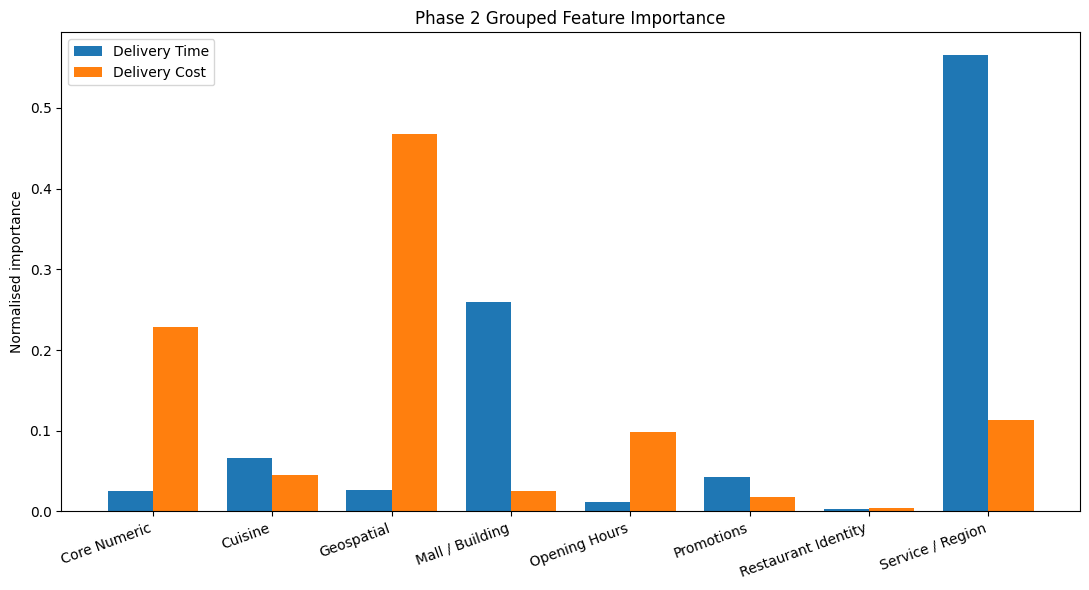

Saved to /Users/jayden/Documents/Grab-Food-Delivery-Time-Cost-Prediction/docs/images/fig_feature_importance.png


In [26]:
all_groups = sorted(set(time_imp) | set(cost_imp))
time_vals  = [time_imp.get(g, 0) for g in all_groups]
cost_vals  = [cost_imp.get(g, 0) for g in all_groups]

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(all_groups))
w = 0.38
ax.bar([i - w/2 for i in x], time_vals, width=w, label='Delivery Time')
ax.bar([i + w/2 for i in x], cost_vals, width=w, label='Delivery Cost')
ax.set_xticks(list(x))
ax.set_xticklabels(all_groups, rotation=20, ha='right')
ax.set_ylabel('Normalised importance')
ax.set_title('Phase 2 Grouped Feature Importance')
ax.legend()
plt.tight_layout()

fig_path = ROOT / 'docs' / 'images' / 'fig_feature_importance.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=180)
plt.show()
print(f'Saved to {fig_path}')

## 8. Save All Artifacts

Writes everything back to the project root so `grab_app.py` picks up the new models:

| File | Purpose |
|---|---|
| `rf_best_time.pkl` / `rf_best_cost.pkl` | Winning models |
| `feature_artifacts.json` | Chain names, building list, centroids, fill values, etc. |
| `final_columns.txt` | Ordered list of 154 feature column names |
| `unique_cuisines.txt` | Top-20 cuisines + Other |
| `other_columns.txt` | Categorical columns that get one-hot encoded |
| `test_dataset.csv` | 10% held-out rows for upload testing in the app |
| `model_metrics.json` | train/test R², MAE, RMSE for both targets |

In [27]:
with open(ROOT / 'xg_best_time.pkl', 'wb') as f:
    pickle.dump(selected_time, f)
with open(ROOT / 'xg_best_cost.pkl', 'wb') as f:
    pickle.dump(selected_cost, f)

save_feature_artifacts(ROOT / 'feature_artifacts.json', feature_artifacts)
write_lines(ROOT / 'final_columns.txt', final_columns)
write_lines(ROOT / 'other_columns.txt', [
    'mall_or_building_name', 'promo_discount_type',
    'delivery_options', 'loc_type', 'delivery_by', 'region',
])
write_lines(ROOT / 'unique_cuisines.txt', feature_artifacts['top_cuisines'] + ['Other'])

drop_cols = [c for c in ['building_name', 'cuisine_list'] if c in test_df.columns]
test_df.drop(columns=drop_cols).to_csv(ROOT / 'test_dataset.csv', index=False)

print('xg_best_time.pkl  saved')
print('xg_best_cost.pkl  saved')
print('feature_artifacts.json saved')
print(f'final_columns.txt saved  ({len(final_columns)} features)')
print(f'test_dataset.csv  saved  ({len(test_df):,} rows)')

xg_best_time.pkl  saved
xg_best_cost.pkl  saved
feature_artifacts.json saved
final_columns.txt saved  (154 features)
test_dataset.csv  saved  (1,590 rows)


In [28]:
# Cross-validation (optional): checks stability across folds.
# NOTE: This runs on the full prepared dataset matrix, so it can take longer.

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
}

def summarize_cv(name, model, X, y):
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'model': name,
        'cv_r2_mean': float(np.mean(scores['test_r2'])),
        'cv_rmse_mean': float(np.mean(np.sqrt(-scores['test_neg_mse']))),
        'cv_mae_mean': float(np.mean(-scores['test_neg_mae'])),
    }

cv_time = pd.DataFrame([
    summarize_cv('Linear', LinearRegression(), X_train, y_train_time),
    summarize_cv('DecisionTree', DecisionTreeRegressor(random_state=42), X_train, y_train_time),
    summarize_cv('RandomForest', RandomForestRegressor(
        n_estimators=300, min_samples_split=10, max_features='sqrt', random_state=42, n_jobs=-1
    ), X_train, y_train_time),
    summarize_cv('XGBoost', XGBRegressor(
        n_estimators=1200, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, min_child_weight=5,
        objective='reg:squarederror', tree_method='hist',
        random_state=42, n_jobs=-1,
    ), X_train, y_train_time),
])

cv_cost = pd.DataFrame([
    summarize_cv('Linear', LinearRegression(), X_train, y_train_cost),
    summarize_cv('DecisionTree', DecisionTreeRegressor(random_state=42), X_train, y_train_cost),
    summarize_cv('RandomForest', RandomForestRegressor(
        n_estimators=300, min_samples_split=10, max_features='sqrt', random_state=42, n_jobs=-1
    ), X_train, y_train_cost),
    summarize_cv('XGBoost', XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, min_child_weight=5,
        objective='reg:squarederror', tree_method='hist',
        random_state=42, n_jobs=-1,
    ), X_train, y_train_cost),
])

print('CV summary — delivery time')
display(cv_time)
print('CV summary — delivery cost')
display(cv_cost)

CV summary — delivery time


,model,cv_r2_mean,cv_rmse_mean,cv_mae_mean
0,Linear,0.523842,10.821626,7.186098
1,DecisionTree,0.427497,11.865080,7.193995
2,RandomForest,0.638437,9.429084,6.031303
3,XGBoost,0.708658,8.460970,5.302795


CV summary — delivery cost


,model,cv_r2_mean,cv_rmse_mean,cv_mae_mean
0,Linear,0.442910,4.929625,3.752912
1,DecisionTree,0.435346,4.959266,2.602005
2,RandomForest,0.640294,3.959472,2.780758
3,XGBoost,0.692636,3.659693,2.301766


In [29]:
time_candidates = {
    'linear': lin_time_metrics,
    'decision_tree': dt_time_metrics,
    'random_forest': rf_time_metrics,
    'xgboost': xgb_time_metrics,
}
cost_candidates = {
    'linear': lin_cost_metrics,
    'decision_tree': dt_cost_metrics,
    'random_forest': rf_cost_metrics,
    'xgboost': xgb_cost_metrics,
}

if 'best_xgb_time' in globals():
    time_candidates.update({
        'random_forest_tuned': best_rf_time_metrics,
        'xgboost_tuned': best_xgb_time_metrics,
    })
    cost_candidates.update({
        'random_forest_tuned': best_rf_cost_metrics,
        'xgboost_tuned': best_xgb_cost_metrics,
    })

metrics_payload = {
    'feature_set': {
        'final_feature_count': len(final_columns),
        'top_buildings_kept':  TOP_BUILDING_COUNT,
        'top_cuisines_kept':   TOP_CUISINE_COUNT,
        'optional_targets_not_used_as_features': list(OPTIONAL_TARGET_COLUMNS),
    },
    'delivery_time': {
        'selected_model': selected_time_name,
        'candidates': time_candidates,
    },
    'delivery_cost': {
        'selected_model': selected_cost_name,
        'candidates': cost_candidates,
    },
}
with open(ROOT / 'model_metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print(json.dumps(metrics_payload, indent=2))

{
  "feature_set": {
    "final_feature_count": 154,
    "top_buildings_kept": 100,
    "top_cuisines_kept": 20,
    "optional_targets_not_used_as_features": [
      "delivery_time",
      "delivery_cost"
    ]
  },
  "delivery_time": {
    "selected_model": "xgboost_tuned",
    "candidates": {
      "linear": {
        "train_mse": 114.3547,
        "test_mse": 103.1758,
        "train_rmse": 10.6937,
        "test_rmse": 10.1575,
        "train_mae": 7.1015,
        "test_mae": 6.816,
        "train_r2": 0.5351,
        "test_r2": 0.5965
      },
      "decision_tree": {
        "train_mse": 0.0047,
        "test_mse": 128.3908,
        "train_rmse": 0.0686,
        "test_rmse": 11.331,
        "train_mae": 0.0014,
        "test_mae": 7.0954,
        "train_r2": 1.0,
        "test_r2": 0.4979
      },
      "random_forest": {
        "train_mse": 45.0973,
        "test_mse": 79.9642,
        "train_rmse": 6.7155,
        "test_rmse": 8.9423,
        "train_mae": 4.2649,
        "test

## 9. Sanity Check — Round-trip Inference

Reloads every artifact from disk and runs inference on 3 held-out rows. Both predictions must succeed and errors should be within a reasonable range.

In [30]:
saved_artifacts = load_feature_artifacts(ROOT / 'feature_artifacts.json')
saved_columns   = read_final_columns(ROOT / 'final_columns.txt')
saved_fill      = saved_artifacts['fill_values']

with open(ROOT / 'xg_best_time.pkl', 'rb') as f:
    loaded_time = pickle.load(f)
with open(ROOT / 'xg_best_cost.pkl', 'rb') as f:
    loaded_cost = pickle.load(f)

sample_raw = test_df.drop(columns=['building_name', 'cuisine_list'], errors='ignore').head(3).copy()
X_sample = transform_for_inference(sample_raw, saved_artifacts, saved_columns, saved_fill)

result = sample_raw[['name', 'region', 'delivery_time', 'delivery_cost']].copy()
result['pred_time'] = loaded_time.predict(X_sample).round(1)
_pred_cost = loaded_cost.predict(X_sample)
_pred_cost = np.clip(_pred_cost, 0.0, None)
result['pred_cost'] = np.round(_pred_cost, 2)
result['time_err']  = (result['pred_time'] - result['delivery_time']).abs().round(1)
result['cost_err']  = (result['pred_cost'] - result['delivery_cost']).abs().round(2)

display(result)
print('Sanity check passed — artifacts round-trip OK.')

,name,region,delivery_time,delivery_cost,pred_time,pred_cost,time_err,cost_err
8001,Cundhi Vegetarian Restaurant,East,42.0,5.4,41.0,12.31,1.0,6.91
10891,Zhong Hua Guo Wang,Northeast,31.0,15.2,29.1,15.17,1.9,0.03
9509,Hey Yogurt,East,34.0,3.3,31.6,8.43,2.4,5.13


Sanity check passed — artifacts round-trip OK.
